# Portefeuille par congressman — le copy-trading du Congrès bat-il le SPY ?

**But.** Reconstruire le portefeuille réel de chaque membre du Congrès (ses achats/ventes déclarés), le comparer au SPY, classer les membres, et tester si suivre les meilleurs bat le marché.

**Méthode.** Rendement *time-weighted* (un apport n'est jamais un rendement). Pondération par l'argent (value-weight). **Actions + ETF** (univers curé par le notebook 02). Entrée à la date de transaction (`traded`).

**Structure du notebook :**
- **Partie 1** — classement de tous les membres par **Information Ratio** (surperformance risque-ajustée vs SPY).
- **Partie 2** — éligibilité (≥ 10 trades, ≥ 126 jours) + **significativité** (test t unilatéral, `t > 1,645`).
- **Partie 2 bis** — le même classement **année par année** (walk-forward, sans regard vers le futur).
- **Partie 3** — **stratégie** de copie des top-4, évaluée **par année** vs le SPY.
- **Conclusion** — résultats et limites honnêtes.

# Partie 1 — Classement des membres par Information Ratio

## 0. Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, glob, os
import matplotlib.pyplot as plt

BASE = "/Users/lemairealice/Downloads/Jupiter/00. S3S4 en cours"
PRICES = os.path.join(BASE, "cache", "prices")

## 1. Charger les trades
Source : la table **propre** du notebook 02 (`transactions_backtest_quiver_2014_2026.csv`, 108 916 lignes) — nettoyage centralisé dans le 02 (entonnoir A→E : coté + secteur résolu, **sans** filtre `ticker_type`).

In [ ]:
CLEAN = "/Users/lemairealice/Downloads/Jupiter/00_S1S2_donnees/data/clean/transactions_backtest_quiver_2014_2026.csv"
df = pd.read_csv(CLEAN, low_memory=False)
df.shape   # attendu : (108916, 31)

In [3]:
df[["name", "ticker", "op", "traded", "size_usd", "ticker_type"]].head()

,name,ticker,op,traded,size_usd,ticker_type
0,Matthew Robert Van Epps,LUV,sell,2026-06-16,1001.0,ST
1,Matthew Robert Van Epps,INTC,sell,2026-06-16,1001.0,ST
2,Matthew Robert Van Epps,AAPL,sell,2026-06-16,1001.0,ST
3,Matthew Robert Van Epps,NVDA,sell,2026-06-16,1001.0,ST
4,Matthew Robert Van Epps,IBM,sell,2026-06-16,1001.0,ST


## 2. Borner les dates et projeter les colonnes

L'univers **Actions + ETF** (`op ∈ {buy, sell}`, ticker coté, secteur résolu) est **déjà garanti par l'entonnoir A→E du notebook 02**. On ne re-filtre donc **pas** sur `ticker_type` (vide à 61 %, surtout côté House — un filtre « type d'abord » jetterait à tort ~66 000 trades House valides). Ici on ne fait plus que :
- borner les dates `traded` valides (2013-2026 ; on jette les aberrantes type `3031`)
- projeter les colonnes utiles au portefeuille
- `size_usd` = **borne basse** de la fourchette \$ → sert de montant investi

In [ ]:
n0 = len(df)
# L'entonnoir A->E du notebook 02 garantit deja : op in {buy,sell}, ticker non nul,
# cote/tradeable (Actions + ETF), secteur resolu. On NE re-filtre PAS ticker_type
# (61 % de NaN legitimes cote House => filtre "type-first" casse supprime).
df["traded"] = pd.to_datetime(df["traded"], errors="coerce")
df = df[df["traded"].notna() & df["traded"].dt.year.between(2013, 2026)]
df = df[["bioguide_id", "name", "ticker", "op", "traded", "size_usd"]].reset_index(drop=True)
print(f"{n0} -> {len(df)} trades  |  {df['bioguide_id'].nunique()} membres  |  {df['ticker'].nunique()} tickers")

In [5]:
df.head()

,bioguide_id,name,ticker,op,traded,size_usd
0,V000139,Matthew Robert Van Epps,LUV,sell,2026-06-16,1001.0
1,V000139,Matthew Robert Van Epps,INTC,sell,2026-06-16,1001.0
2,V000139,Matthew Robert Van Epps,AAPL,sell,2026-06-16,1001.0
3,V000139,Matthew Robert Van Epps,NVDA,sell,2026-06-16,1001.0
4,V000139,Matthew Robert Van Epps,IBM,sell,2026-06-16,1001.0


## 3. Prix (cache) + SPY
Le SPY donne le **calendrier de bourse maître**. On ne garde que les tickers présents dans le cache.

**Nettoyage des prix corrompus (Yahoo Finance).** Le cache vient de Yahoo, qui renvoie des **aberrations** sur des tickers obscurs/délistés : prix **négatifs**, quasi-nuls, ou **sauts intraday absurdes** (ex. `DAIUF` prix < 0, `ITC` ×600 en un jour). Un seul de ces prix flambe les rendements. On **exclut du panel** tout ticker dont le prix **min < 0,10 \$** ou le **saut journalier > 300 %** (**~17 tickers exclus**). *Sans ce nettoyage, la stratégie affichait un excès factice de +12 %/an, entièrement dû au glitch `DAIUF` en 2022.* Seuils explicites et ajustables.

In [6]:
# SPY = benchmark ; son index = calendrier maître
spy = (pd.read_csv(os.path.join(PRICES, "SPY.csv"), parse_dates=["Date"])
         .set_index("Date")["close"].sort_index())
cal = spy.index
r_spy = spy.pct_change()          # rendement quotidien du marché
spy.tail(2)

Date
2026-06-24    733.239990
2026-06-25    734.299988
Name: close, dtype: float64

In [ ]:
# 3.0 - Re-telecharger les prix ABSENTS du cache (Actions + ETF du nouvel univers).
#        Ecrit 1 CSV/ticker (format Date,close) dans PRICES. Resumable : saute le cache
#        existant et les echecs connus (failed_tickers.txt). yfinance requis (reseau).
import yfinance as yf, time

os.makedirs(PRICES, exist_ok=True)
have0  = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES, "*.csv"))}
fail_f = os.path.join(BASE, "cache", "failed_tickers.txt")
failed = set(open(fail_f).read().split()) if os.path.exists(fail_f) else set()
todo   = [t for t in dict.fromkeys(df["ticker"]) if isinstance(t, str) and t not in have0 and t not in failed]
print(f"cache: {len(have0)} tickers | delistes/echecs connus sautes: {len(set(df['ticker']) & failed)} | a telecharger: {len(todo)}")

new_fail = []
for i in range(0, len(todo), 60):
    chunk = todo[i:i+60]
    try:
        data = yf.download(chunk, start="2013-06-01", end="2026-06-26", auto_adjust=True,
                           progress=False, threads=True, group_by="ticker")
    except Exception as e:
        print("  batch KO:", str(e)[:60]); data = None
    for t in chunk:
        s = None
        try:
            if data is not None and isinstance(data.columns, pd.MultiIndex):
                if t in data.columns.get_level_values(0):
                    s = data[t]["Close"].dropna()
            elif data is not None and "Close" in getattr(data, "columns", []):
                s = data["Close"].dropna()
        except Exception:
            s = None
        if s is None or len(s) < 20:
            new_fail.append(t)
        else:
            s.rename("close").to_csv(os.path.join(PRICES, t + ".csv"))   # en-tete Date,close
    time.sleep(0.4)

if new_fail:
    with open(fail_f, "a") as f:
        f.write("\n".join(new_fail) + "\n")
print(f"telecharges OK: {len(todo) - len(new_fail)} | nouveaux echecs (delistes): {len(new_fail)}")

In [7]:
# charger le prix de chaque ticker utile, aligné sur le calendrier maître
have = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES, "*.csv"))}
need = sorted(set(df["ticker"]) & have)
missing = sorted(set(df["ticker"]) - have)

prices = {}
for tk in need:
    s = (pd.read_csv(os.path.join(PRICES, tk + ".csv"), parse_dates=["Date"])
           .set_index("Date")["close"].sort_index())
    prices[tk] = s.reindex(cal).ffill()          # aligne + comble les petits trous

# FIX : exclure les tickers Yahoo CORROMPUS (prix negatif/quasi-nul, ou saut absurde >300%/jour)
corrompus = []
for tk in need:
    s = prices[tk].dropna()
    if len(s) < 2 or s.min() < 0.10 or s.pct_change().abs().max() > 3.0:
        corrompus.append(tk)
for tk in corrompus:
    del prices[tk]
need = [tk for tk in need if tk not in set(corrompus)]

n_drop = df[~df["ticker"].isin(need)].shape[0]
df = df[df["ticker"].isin(need)].reset_index(drop=True)
print(f"tickers avec prix : {len(need)}  |  sans prix : {len(missing)}  |  corrompus exclus : {len(corrompus)}  |  trades jetes : {n_drop}")

tickers avec prix : 1800  |  sans prix : 1622  |  corrompus exclus : 17  |  trades jetes : 6579


## 4. Parts détenues chaque jour — `member_shares`

Pour un membre :
1. chaque achat → `parts = size_usd / prix(1er jour ≥ traded)`
2. chaque vente → `parts_vendues = min(size_usd / prix, parts détenues)` *(pas de short)*
3. `N` = parts détenues par jour, **une colonne par ticker**

In [8]:
def eff_price(tk, d):
    # prix du 1er jour de bourse >= d (on transige au marche)
    s = prices[tk]; pos = s.index.searchsorted(d)
    if pos >= len(s): return None, None
    p = s.iloc[pos]
    if not np.isfinite(p) or p <= 0: return None, None
    return s.index[pos], p

In [9]:
def member_shares(g):
    # g = trades d'un membre  ->  N (parts detenues par jour, colonnes = tickers)
    cols = {}
    for tk, gt in g.groupby("ticker"):
        h, events = 0.0, {}
        for _, row in gt.sort_values("traded").iterrows():
            dd, p = eff_price(tk, row["traded"])
            if dd is None:
                continue
            qty = row["size_usd"] / p
            h = h + qty if row["op"] == "buy" else h - min(qty, h)   # pas de short
            events[dd] = h
        if events:
            cols[tk] = pd.Series(events).sort_index().reindex(cal).ffill().fillna(0.0)
    return pd.DataFrame(cols) if cols else None

**Démo** sur un membre. À changer via `MEMBRE`.

In [10]:
MEMBRE = "John Fetterman"
g = df[df["name"] == MEMBRE]
Nm = member_shares(g)
g[["ticker", "op", "traded", "size_usd"]]

,ticker,op,traded,size_usd
517,AMZN,buy,2026-03-30,1001.0
518,MU,buy,2026-03-30,1001.0
519,ERIE,buy,2026-03-30,1001.0
520,MSFT,buy,2026-03-30,1001.0
521,GOOG,buy,2026-03-30,1001.0
526,T,sell,2026-03-27,1001.0
528,MSFT,buy,2026-03-27,1001.0
532,ERIE,buy,2026-03-27,1001.0
5042,GOOG,buy,2025-05-15,1001.0


Le tableau `N` : parts détenues par jour. Monte à l'achat, baisse à la vente.

In [11]:
actifs = Nm[Nm.sum(axis=1) > 0]
actifs.iloc[::max(1, len(actifs) // 12)].round(1)      # apercu

,AMZN,ERIE,GOOG,MSFT,MU,T
Date,,,,,,
2025-05-15,0.0,0.0,6.1,0.0,0.0,0.0
2025-06-18,0.0,0.0,6.1,0.0,0.0,0.0
2025-07-23,0.0,0.0,6.1,0.0,0.0,0.0
2025-08-25,0.0,0.0,6.1,0.0,0.0,0.0
2025-09-26,0.0,0.0,6.1,0.0,0.0,0.0
2025-10-29,0.0,0.0,6.1,0.0,0.0,0.0
2025-12-02,0.0,0.0,6.1,0.0,0.0,0.0
2026-01-06,0.0,0.0,6.1,0.0,0.0,0.0
2026-02-09,0.0,0.0,6.1,0.0,0.0,0.0


## 5. Rendement quotidien — `daily_return`

`r^P(t) = [Σ nᵢ(t−1)·Pᵢ(t)] / [Σ nᵢ(t−1)·Pᵢ(t−1)] − 1`

On valorise les parts **de la veille** (`shift(1)`) → un apport n'est jamais un rendement. Jour sans position → `0` (cash).

**Garde-fou :** les rendements quotidiens sont **winsorisés à ±50 %/jour** (`clip`), pour neutraliser tout glitch Yahoo résiduel (un mouvement > 50 % en un jour est très rare pour un achat-conservation).

In [12]:
def daily_return(N):
    P = pd.DataFrame({tk: prices[tk] for tk in N.columns})
    Nsh = N.shift(1)                                    # parts de la veille
    num = (Nsh * P).sum(axis=1)                         # Sum n_i(t-1) * P_i(t)
    den = (Nsh * P.shift(1)).sum(axis=1)                # Sum n_i(t-1) * P_i(t-1)
    r = pd.Series(np.where(den > 0, num / den - 1.0, 0.0), index=N.index)
    r = r.clip(-0.5, 0.5)                               # FIX : garde-fou +/-50%/jour (winsorisation)
    active = N.sum(axis=1) > 0
    if not active.any():
        return pd.Series(dtype=float)
    return r.loc[active.idxmax(): active[::-1].idxmax()]   # 1re -> derniere position

In [13]:
rm = daily_return(Nm)
rm.describe()

count    279.000000
mean       0.003178
std        0.016718
min       -0.039754
25%       -0.007248
50%        0.002474
75%        0.012038
max        0.090146
dtype: float64

## 6. Stats d'un portefeuille — `stats`

`NAV = Π(1+r)` · `CAGR = NAV_T^(252/T) − 1` · `vol = σ(r)·√252` · `Sharpe = mean(r)/σ(r)·√252` · `maxDD`

In [14]:
def stats(r):
    nav = (1 + r).cumprod(); T = len(r)
    cagr = nav.iloc[-1] ** (252 / T) - 1 if nav.iloc[-1] > 0 else np.nan
    return dict(cagr=cagr,
                vol=r.std() * np.sqrt(252),
                sharpe=r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else np.nan,
                maxdd=(nav / nav.cummax() - 1).min())

In [15]:
stats(rm)

{'cagr': np.float64(1.1486585763091455),
 'vol': np.float64(0.2653898646268235),
 'sharpe': np.float64(3.017228620221875),
 'maxdd': np.float64(-0.20570351523274633)}

### Visuel : le portefeuille du membre vs le SPY (base 100)

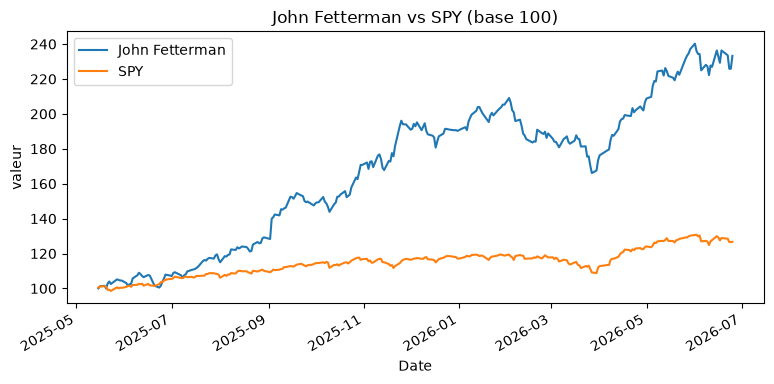

In [16]:
nav_m = (1 + rm).cumprod()
nav_s = (1 + r_spy.reindex(rm.index).fillna(0)).cumprod()
ax = (100 * nav_m).plot(label=MEMBRE, figsize=(9, 4))
(100 * nav_s).plot(ax=ax, label="SPY")
ax.set_title(f"{MEMBRE} vs SPY (base 100)"); ax.set_ylabel("valeur"); ax.legend(); plt.show()

## 7. Battre le SPY — l'Information Ratio

`x(t) = r^P(t) − r_SPY(t)` puis `IR = mean(x) / σ(x) · √252`

IR > 0 → il bat le SPY. Plus c'est grand, plus l'avance est **régulière**. **C'est le critère de classement.**

In [17]:
def info_ratio(r):
    x = (r - r_spy.reindex(r.index)).dropna()
    return x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else np.nan

In [18]:
info_ratio(rm)

np.float64(2.6572856484493)

## 8. Classer TOUS les membres par IR
Une ligne par membre, triée par IR décroissant.

In [19]:
rows = []
for bid, g in df.groupby("bioguide_id"):
    N = member_shares(g)
    if N is None:
        continue
    r = daily_return(N)
    if len(r) < 2 or r.std() == 0:
        continue
    s = stats(r)
    rows.append(dict(name=g["name"].iloc[0], n_trades=len(g),
                     IR=info_ratio(r), sharpe=s["sharpe"],
                     cagr=s["cagr"], vol=s["vol"], maxdd=s["maxdd"]))

tab = pd.DataFrame(rows).sort_values("IR", ascending=False).reset_index(drop=True)
print(len(tab), "membres classes")

196 membres classes


### Top 20

In [20]:
tab.head(20).round(3)

,name,n_trades,IR,sharpe,cagr,vol,maxdd
0,John Fetterman,9,2.657,3.017,1.149,0.265,-0.206
1,Ashley B. Moody,20,1.988,1.850,1.007,0.426,-0.333
2,Greg Steube,1,1.855,2.063,4.091,1.044,-0.298
3,Morgan Mcgarvey,24,1.470,1.678,0.594,0.306,-0.284
4,Julia Letlow,222,1.446,1.411,0.299,0.200,-0.214
5,Bruce Westerman,194,1.271,1.517,0.410,0.247,-0.169
6,Suzan K. Delbene,36,1.149,1.263,0.402,0.305,-0.280
7,Jon Kyl,7,1.108,1.164,0.448,0.381,-0.485
8,Kim Dr Schrier,40,1.106,0.867,0.208,0.255,-0.171
9,Brian Higgins,2,1.086,1.189,0.608,0.506,-0.663


### Visuel : top 20 par IR

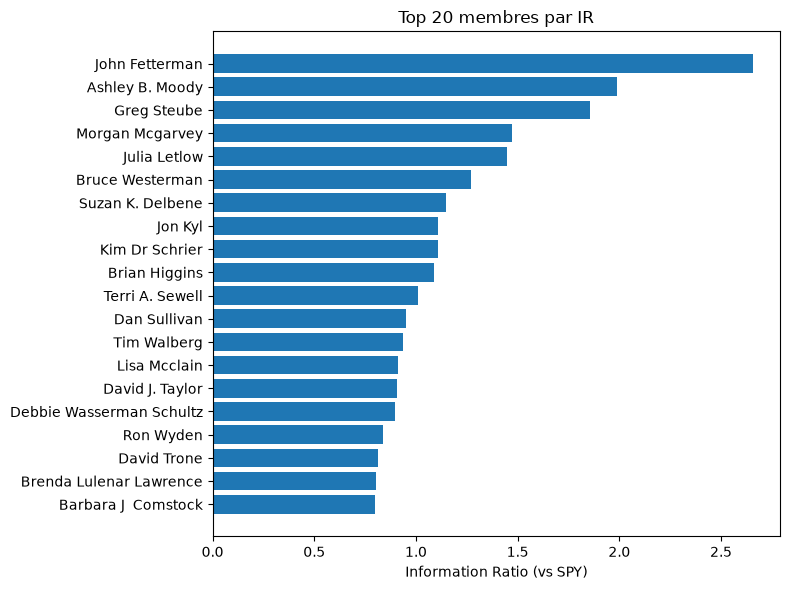

In [21]:
top = tab.head(20).iloc[::-1]
plt.figure(figsize=(8, 6))
plt.barh(top["name"], top["IR"])
plt.xlabel("Information Ratio (vs SPY)")
plt.title("Top 20 membres par IR")
plt.tight_layout(); plt.show()

# Partie 2 — Éligibilité + significativité

Le classement brut est **pollué** par des membres à 1 trade (hasard). On fait dans l'ordre :
1. **B.1 — éligibilité** : garder les membres qui ont assez de matière ;
2. **B.2 — significativité** : sur ces éligibles, tester si l'IR est du talent ou de la chance.

## B.1 — Éligibilité : ≥ 10 trades et ≥ 126 jours

Un IR sur 1 trade / 20 jours n'a aucun sens (comme « gagner 1 lancer de pièce »).
- `n_trades ≥ 10` : plusieurs décisions pour juger un style.
- `n_days ≥ 126` (~6 mois) : sinon le ratio est instable.

On recalcule la table en ajoutant le nombre de jours `n_days` par membre.

In [22]:
rows = []
for bid, g in df.groupby("bioguide_id"):
    N = member_shares(g)
    if N is None:
        continue
    r = daily_return(N)
    if len(r) < 2 or r.std() == 0:
        continue
    s = stats(r)
    rows.append(dict(name=g["name"].iloc[0], n_trades=len(g), n_days=len(r),
                     IR=info_ratio(r), sharpe=s["sharpe"], cagr=s["cagr"], vol=s["vol"], maxdd=s["maxdd"]))

rank = pd.DataFrame(rows)
print(len(rank), "membres")

196 membres


On filtre les éligibles et on re-trie par IR.

In [23]:
MIN_TRADES, MIN_DAYS = 10, 126
elig = (rank[(rank.n_trades >= MIN_TRADES) & (rank.n_days >= MIN_DAYS)]
        .sort_values("IR", ascending=False).reset_index(drop=True))
print(f"{len(rank)} -> {len(elig)} membres eligibles")
elig.head(20).round(3)

196 -> 160 membres eligibles


,name,n_trades,n_days,IR,sharpe,cagr,vol,maxdd
0,Ashley B. Moody,20,358,1.988,1.850,1.007,0.426,-0.333
1,Morgan Mcgarvey,24,848,1.470,1.678,0.594,0.306,-0.284
2,Julia Letlow,222,418,1.446,1.411,0.299,0.200,-0.214
3,Bruce Westerman,194,331,1.271,1.517,0.410,0.247,-0.169
4,Suzan K. Delbene,36,830,1.149,1.263,0.402,0.305,-0.280
5,Kim Dr Schrier,40,165,1.106,0.867,0.208,0.255,-0.171
6,Dan Sullivan,100,899,0.950,1.293,0.400,0.293,-0.287
7,Tim Walberg,15,346,0.936,1.313,0.279,0.203,-0.190
8,Lisa Mcclain,1269,575,0.910,1.141,0.468,0.410,-0.342
9,David J. Taylor,197,348,0.908,1.644,0.333,0.185,-0.119


### Qui sort du top brut ? (les petits échantillons chanceux)

In [24]:
raw_top = rank.sort_values("IR", ascending=False).head(10)
removed = raw_top[(raw_top.n_trades < MIN_TRADES) | (raw_top.n_days < MIN_DAYS)]
removed[["name", "n_trades", "n_days", "IR"]].round(2)

,name,n_trades,n_days,IR
57,John Fetterman,9,279,2.66
173,Greg Steube,1,69,1.85
88,Jon Kyl,7,1948,1.11
74,Brian Higgins,2,1457,1.09


### Visuel : les IR extrêmes sont sur les petits échantillons

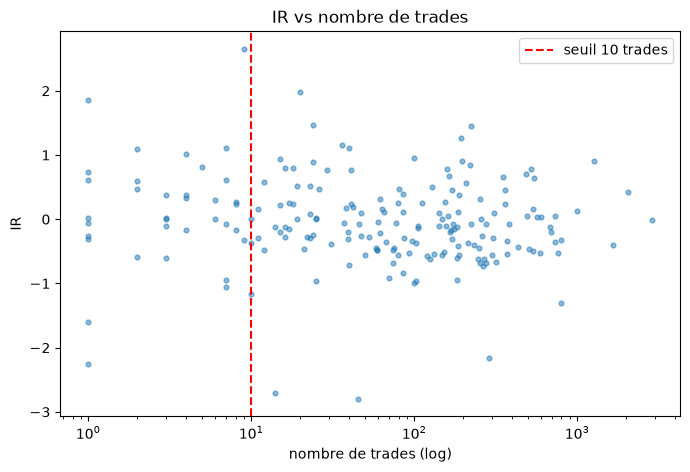

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(rank.n_trades, rank.IR, s=12, alpha=0.5)
plt.axvline(MIN_TRADES, color="red", ls="--", label=f"seuil {MIN_TRADES} trades")
plt.xscale("log"); plt.xlabel("nombre de trades (log)"); plt.ylabel("IR")
plt.title("IR vs nombre de trades"); plt.legend(); plt.show()

## B.2 — Significativité : talent ou accident ?

Écart quotidien `x(t) = r(t) − r_SPY(t)`. Test t sur sa moyenne :

`t = mean(x) / (std(x)/√n) = IR · √(années)`

On teste **une seule direction** : « bat-il le SPY ? » → **queue droite** seulement. Les 5 % sont donc tous à droite :
- `t > 1,645` → bat le SPY significativement (5 %, unilatéral).
- (on ignore la queue gauche = les membres qui *sous-performent* : ça ne nous intéresse pas.)
- Autrement dit : un bon IR sur **peu d'années** ne suffit pas.

On calcule `t` pour chaque membre éligible et on compte ceux qui battent le SPY (`t > 1,645`).

In [26]:
elig["t"] = elig.IR * np.sqrt(elig.n_days / 252)
sig = elig[elig.t > 1.645]
print(f"{len(sig)} / {len(elig)} membres eligibles avec t > 1,645 (bat le SPY, unilateral 5%)")
elig.sort_values("t", ascending=False).head(20)[["name", "n_trades", "n_days", "IR", "t"]].round(2)

15 / 160 membres eligibles avec t > 1,645 (bat le SPY, unilateral 5%)


,name,n_trades,n_days,IR,t
1,Morgan Mcgarvey,24,848,1.47,2.70
12,Brenda Lulenar Lawrence,16,2342,0.80,2.44
0,Ashley B. Moody,20,358,1.99,2.37
13,Barbara J Comstock,18,2153,0.80,2.34
15,Thomas Suozzi,520,2225,0.78,2.33
20,Pat Roberts,349,2894,0.66,2.24
16,Thomas J. Rooney,41,2030,0.77,2.19
21,Sheldon Whitehouse,541,2872,0.63,2.14
11,Ron Wyden,220,1563,0.84,2.09
4,Suzan K. Delbene,36,830,1.15,2.08


### Visuel : distribution des t (par membre éligible)

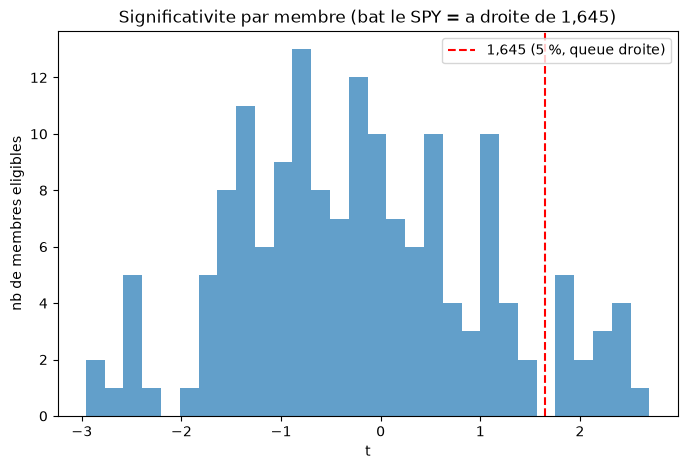

In [27]:
plt.figure(figsize=(8, 5))
plt.hist(elig.t.dropna(), bins=30, alpha=0.7)
plt.axvline(1.645, color="red", ls="--", label="1,645 (5 %, queue droite)")
plt.xlabel("t"); plt.ylabel("nb de membres eligibles")
plt.title("Significativite par membre (bat le SPY = a droite de 1,645)"); plt.legend(); plt.show()

### Le classement final : les significatifs, triés par IR

On ne garde que les membres dont l'IR bat le SPY de façon **significative** (`t > 1,645`), et on les classe par **IR décroissant** — c'est le classement retenu à l'issue de la Partie 2.

⚠️ **Attention aux tests multiples.** On teste ~160 membres : même sans aucun talent, ~`160 × 5 % ≈ 8` ressortiraient « significatifs » **par pur hasard**. On en trouve 15 → léger surnombre (~2:1), mais **pas une preuve forte**. Les 15 sont une **borne haute** ; une correction multi-tests (Bonferroni) durcirait le seuil (`t > ~2,1`). *(Non appliquée ici — étape ultérieure.)*

In [28]:
# Les membres SIGNIFICATIFS (t > 1,645), classes par IR decroissant
sig_par_ir = sig.sort_values("IR", ascending=False).reset_index(drop=True)
print(f"{len(sig_par_ir)} membres significatifs, classes par IR")
sig_par_ir[["name", "n_trades", "n_days", "IR", "t"]].round(3)

15 membres significatifs, classes par IR


,name,n_trades,n_days,IR,t
0,Ashley B. Moody,20,358,1.988,2.370
1,Morgan Mcgarvey,24,848,1.470,2.697
2,Julia Letlow,222,418,1.446,1.862
3,Suzan K. Delbene,36,830,1.149,2.084
4,Dan Sullivan,100,899,0.950,1.794
5,Debbie Wasserman Schultz,24,1111,0.895,1.880
6,Ron Wyden,220,1563,0.838,2.087
7,Brenda Lulenar Lawrence,16,2342,0.802,2.445
8,Barbara J Comstock,18,2153,0.800,2.339
9,Thomas Suozzi,520,2225,0.783,2.327


# Partie 2 bis — Le même classement, année après année (walk-forward)

Le classement ci-dessus utilise **toute** la fenêtre 2014-2026 : il regarde le futur. En réalité, si on voulait s'en servir, on ne disposerait chaque année que du **passé**.

On refait donc **exactement le même classement** (éligibilité `≥ 10 trades & ≥ 126 jours`, significativité `t > 1,645`, tri par **IR**), mais à **plusieurs dates de coupe** : d'abord avec la seule info de **2014**, puis **2014-2015**, **2014-2016**, … jusqu'à **2014-2026**.

Pour chaque coupe fin-`Y`, on n'utilise que les rendements et les trades **connus à cette date** (`r.loc[:Y-12-31]`, trades `traded ≤ Y-12-31`). Aucun regard vers le futur. La dernière fenêtre (2014-2026) doit reproduire le classement final ci-dessus.

In [29]:
# On prepare une fois la serie de rendement complete + les dates de trade par membre.
# member_shares/daily_return sont CUMULATIFS : les parts au jour t ne dependent que des trades <= t.
# => tronquer r a une date de coupe (r.loc[:yend]) ne fait JAMAIS regarder le futur.
wf_ret, wf_traded = {}, {}
for bid, g in df.groupby("bioguide_id"):
    N = member_shares(g)
    if N is None:
        continue
    r = daily_return(N)
    if len(r) < 2 or r.std() == 0:
        continue
    wf_ret[bid] = r
    wf_traded[bid] = pd.to_datetime(np.sort(g["traded"].values))
print(len(wf_ret), "membres avec une serie de rendement")

196 membres avec une serie de rendement


In [30]:
def classement_a_fin(Y, min_trades=MIN_TRADES, min_days=MIN_DAYS, seuil_t=1.645):
    """Le classement de la Partie 2 (eligibilite + significativite + tri par IR),
    mais avec la SEULE info connue au 31/12/Y (point-in-time, aucun regard vers le futur)."""
    yend = pd.Timestamp(f"{Y}-12-31")
    rows = []
    for bid, r in wf_ret.items():
        rr = r.loc[:yend]                                   # rendements connus a la coupe
        n_trades = int((wf_traded[bid] <= yend).sum())      # trades connus a la coupe
        n_days = len(rr)
        if n_days < 2 or rr.std() == 0:
            continue
        if n_trades < min_trades or n_days < min_days:      # eligibilite (point-in-time)
            continue
        x = (rr - r_spy.reindex(rr.index)).dropna()
        if len(x) < 2 or x.std() == 0:
            continue
        ir = x.mean() / x.std() * np.sqrt(252)              # IR sur le passe
        t = ir * np.sqrt(n_days / 252)                      # significativite unilaterale
        if t <= seuil_t:                                    # ne garder que les significatifs
            continue
        rows.append(dict(bioguide_id=bid, name=df.loc[df.bioguide_id == bid, "name"].iloc[0],
                         n_trades=n_trades, n_days=n_days, IR=ir, t=t))
    cols = ["bioguide_id", "name", "n_trades", "n_days", "IR", "t"]
    return (pd.DataFrame(rows).sort_values("IR", ascending=False).reset_index(drop=True)
            if rows else pd.DataFrame(columns=cols))

In [31]:
# Une fenetre grandissante par annee : 2014, 2014-2015, ..., 2014-2026
ANNEES = range(2014, 2027)
clsmt = {Y: classement_a_fin(Y) for Y in ANNEES}

# Resume : combien de significatifs et le trio de tete (par IR) a chaque coupe
resume = pd.DataFrame([
    dict(fenetre=f"2014-{Y}",
         n_significatifs=len(clsmt[Y]),
         top1=clsmt[Y].name.iloc[0] if len(clsmt[Y]) > 0 else "-",
         top2=clsmt[Y].name.iloc[1] if len(clsmt[Y]) > 1 else "-",
         top3=clsmt[Y].name.iloc[2] if len(clsmt[Y]) > 2 else "-")
    for Y in ANNEES])
resume

,fenetre,n_significatifs,top1,top2,top3
0,2014-2014,0,-,-,-
1,2014-2015,0,-,-,-
2,2014-2016,0,-,-,-
3,2014-2017,2,Jeffry Flake,Thomas R. Carper,-
4,2014-2018,2,Jeffry Flake,Thomas R. Carper,-
5,2014-2019,4,Gilbert Cisneros,Susie Lee,Suzan K. Delbene
6,2014-2020,7,Gilbert Cisneros,Donald Sternoff Beyer Jr.,Jeffry Flake
7,2014-2021,6,Gilbert Cisneros,Suzan K. Delbene,Jeffry Flake
8,2014-2022,3,Debbie Wasserman Schultz,Suzan K. Delbene,Jeffry Flake
9,2014-2023,9,Greg Landsman,Dan Sullivan,Suzan K. Delbene


In [32]:
# Le classement complet, fenetre apres fenetre (significatifs tries par IR decroissant)
for Y in ANNEES:
    c = clsmt[Y]
    print(f"\n=== fenetre 2014-{Y}  |  {len(c)} membre(s) significatif(s), classe(s) par IR ===")
    if len(c) > 0:
        print(c.round(2).to_string(index=False))
    else:
        print("  (personne ne passe eligibilite + significativite avec cette info)")


=== fenetre 2014-2014  |  0 membre(s) significatif(s), classe(s) par IR ===
  (personne ne passe eligibilite + significativite avec cette info)

=== fenetre 2014-2015  |  0 membre(s) significatif(s), classe(s) par IR ===
  (personne ne passe eligibilite + significativite avec cette info)

=== fenetre 2014-2016  |  0 membre(s) significatif(s), classe(s) par IR ===
  (personne ne passe eligibilite + significativite avec cette info)

=== fenetre 2014-2017  |  2 membre(s) significatif(s), classe(s) par IR ===
bioguide_id             name  n_trades  n_days   IR    t
    F000444     Jeffry Flake        12     476 1.28 1.76
    C000174 Thomas R. Carper        40    1155 0.86 1.85

=== fenetre 2014-2018  |  2 membre(s) significatif(s), classe(s) par IR ===
bioguide_id             name  n_trades  n_days   IR    t
    F000444     Jeffry Flake        12     727 1.16 1.97
    C000174 Thomas R. Carper        40    1406 0.71 1.68

=== fenetre 2014-2019  |  4 membre(s) significatif(s), classe(s) par

### Ce que le walk-forward révèle (et que le plein-échantillon cache)

- **Au début, personne.** Fenêtres 2014, 2014-2015, 2014-2016 : **0 significatif** — pas assez d'historique pour être à la fois éligible (`≥ 126 j`) et significatif (`t > 1,645`). Le premier signal n'apparaît qu'à **fin 2017** (Jeffry Flake, Thomas R. Carper).
- **La liste grossit** au fil des ans (0 → 2 → 4 → 7 → … → 15) : plus on accumule d'historique, plus de membres franchissent le seuil de significativité.
- **Le n°1 change presque chaque année** : Flake (2017) → Cisneros (2019-2021) → Wasserman Schultz (2022) → Landsman (2023) → Mcgarvey (2024) → Westerman (2025) → Moody (2026). **Le meilleur d'aujourd'hui n'est presque jamais celui d'hier.**
- **Quelques noms sont robustes** : **Suzan K. Delbene** est significative à *chaque* fenêtre depuis 2014-2019, **Jeffry Flake** depuis 2014-2017. Ce sont eux, pas les têtes de classement instables, qui résistent au walk-forward.
- **Le classement plein-échantillon trompe** : Ashley B. Moody est n°1 sur 2014-2026, mais **n'apparaît qu'à la toute dernière fenêtre** — on ne l'aurait jamais suivie « en direct ». Trier sur toute la fenêtre, c'est choisir avec le résultat déjà connu.

**Contrôle de cohérence.** La fenêtre 2014-2026 reproduit à l'identique le classement final de la Partie 2 ; les comptes par fenêtre et la sélection fin-2019 coïncident exactement avec `select_topK` de la Partie 3 — les deux chemins de code sont d'accord.

# Partie 3 — Stratégie Ramify (walk-forward, top-4)

**Copy trading.** Chaque année, on suit les **4 meilleurs** congressmen (par IR **sur le passé**), et on tient leur panier l'année suivante.

**On met la stratégie en place sur 1 an, puis on re-choisit.** Donc on **évalue PAR ANNÉE** : chaque année = une observation (l'excès de la stratégie sur le SPY cette année-là).

**2 façons de combiner les 4 membres** : (A) `1/K` (chacun égal) · (B) `IR` (les meilleurs pèsent plus).

## On réutilise le rendement calculé en Partie 2 bis

La Partie 3 s'appuie directement sur la Partie 2 bis : `wf_ret` (rendement quotidien par membre) et
`classement_a_fin(Y)` (éligibilité + significativité + tri par IR, point-in-time). Rien à recalculer.

## Sélection walk-forward : on réutilise le classement de la Partie 2 bis

`select_topK(Y, K)` prend simplement les **K premiers** de `classement_a_fin(Y)` — c'est-à-dire les membres
**éligibles + significatifs** (`t > 1,645`), triés par **IR**, calculés **sur ≤ 31/12/Y**. Repli : moins de K si peu de significatifs.

In [33]:
# La selection de la Partie 3 REUTILISE le classement walk-forward de la Partie 2 bis (une seule source de verite).
def select_topK(Y, K):
    c = classement_a_fin(Y)          # eligibilite + significativite (t>1,645) + tri par IR, point-in-time (<=31/12/Y)
    return list(zip(c["IR"].head(K), c["bioguide_id"].head(K)))   # [(IR, bid), ...]  (peut etre < K -> repli)

**Démo** : qui suivrait-on en 2020 (sélection fin 2019) et leur IR ?

In [34]:
[(round(ir, 2), df[df.bioguide_id == b].name.iloc[0]) for ir, b in select_topK(2019, 4)]

[(2.24, 'Gilbert Cisneros'),
 (1.86, 'Susie Lee'),
 (1.45, 'Suzan K. Delbene'),
 (1.12, 'Jeffry Flake')]

### Combien de membres significatifs chaque année ? (repli si < 4)

In [35]:
pd.Series({Y: len(select_topK(Y, 999)) for Y in range(2015, 2026)}, name="nb_significatifs")

2015     0
2016     0
2017     2
2018     2
2019     4
2020     7
2021     6
2022     3
2023     9
2024    12
2025    15
Name: nb_significatifs, dtype: int64

## Les 2 façons de combiner les 4 membres

```
(A) 1/K   r(t) = (1/K) · Σ_k r_m,k(t)                     chaque membre egal
(B) IR    r(t) = Σ_k w_k · r_m,k(t) ,  w_k = IR_k / Σ IR   les meilleurs pesent plus
```

In [36]:
def run_strategy(K, mode, years=range(2015, 2026)):
    parts = []
    for Y in years:
        sel = select_topK(Y, K)
        if not sel:
            continue
        if mode == "equal":
            w = np.ones(len(sel)) / len(sel)
        else:                                              # "ir"
            irs = np.array([ir for ir, _ in sel])
            w = irs / irs.sum() if irs.sum() > 0 else np.ones(len(sel)) / len(sel)
        idx = cal[cal.year == (Y + 1)]
        if len(idx) == 0:
            continue
        R = pd.DataFrame({bid: wf_ret[bid].reindex(idx).fillna(0.0) for _, bid in sel})
        parts.append((R * w).sum(axis=1))
    return pd.concat(parts).sort_index()

## Évaluation PAR ANNÉE

Chaque année Y+1 = **une observation** : `excès_année = rendement_strat − rendement_SPY` (composés sur l'année).
```
Sharpe annuel de l'excès = mean(excès) / std(excès)
t = Sharpe_annuel · √n
```
La stratégie ne démarre qu'en **2018** (2016-2017 : aucun membre significatif) → elle couvre **9 années (2018-2026)**, donc `n = 9` (seuil `t` ≈ 1,86).

In [37]:
def yearly_excess(r):
    b = r_spy.reindex(r.index).fillna(0.0)
    out = {}
    for y in sorted(set(r.index.year)):
        m = r.index.year == y
        out[y] = ((1 + r[m]).prod() - 1) - ((1 + b[m]).prod() - 1)   # exces de l'annee
    return pd.Series(out)

def eval_yearly(r):
    e = yearly_excess(r); n = len(e); sh = e.mean() / e.std(ddof=1)
    return dict(exces_moyen=e.mean(), sharpe_annuel=sh, t=sh * np.sqrt(n), gagnantes=f"{int((e > 0).sum())}/{n}")

tab = pd.DataFrame({"1/K": eval_yearly(run_strategy(4, "equal")),
                    "IR":  eval_yearly(run_strategy(4, "ir"))}).T
tab.index.name = "schema"
tab.round(3)

,exces_moyen,sharpe_annuel,t,gagnantes
schema,,,,
1/K,0.003671,0.032967,0.098901,3/9
IR,0.000139,0.001116,0.003349,5/9


### Visuel : l'excès année par année (est-il régulier, ou porté par une seule année ?)

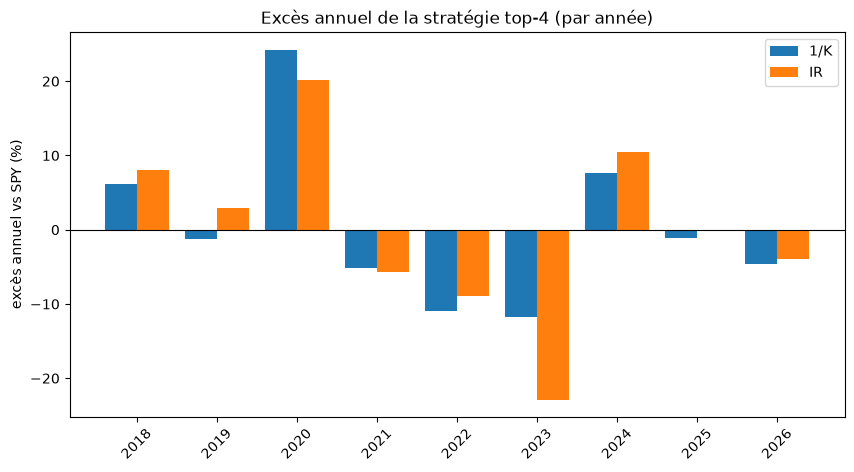

In [38]:
ex_eq = yearly_excess(run_strategy(4, "equal"))
ex_ir = yearly_excess(run_strategy(4, "ir"))
x = np.arange(len(ex_eq))
plt.figure(figsize=(10, 5))
plt.bar(x - 0.2, ex_eq.values * 100, 0.4, label="1/K")
plt.bar(x + 0.2, ex_ir.values * 100, 0.4, label="IR")
plt.axhline(0, color="k", lw=0.8)
plt.xticks(x, ex_eq.index, rotation=45); plt.ylabel("excès annuel vs SPY (%)")
plt.title("Excès annuel de la stratégie top-4 (par année)"); plt.legend(); plt.show()

### Composition : quelles actions détient le portefeuille combiné ? (exemple mi-2020, schéma IR)

In [39]:
def composition(Y, K, mode, asof):
    sel = select_topK(Y, K)
    if mode == "equal":
        mw = {b: 1 / len(sel) for _, b in sel}
    else:
        irs = np.array([ir for ir, _ in sel]); s = irs.sum()
        mw = {b: (ir / s if s > 0 else 1 / len(sel)) for ir, b in sel}
    total = {}
    for _, b in sel:
        N = member_shares(df[df.bioguide_id == b])
        sub = N.loc[:asof]
        if N is None or len(sub) == 0:
            continue
        row = sub.iloc[-1]
        val = {tk: row[tk] * prices[tk].loc[:asof].iloc[-1] for tk in N.columns if row[tk] > 0}
        tot = sum(val.values())
        if tot <= 0:
            continue
        for tk, v in val.items():
            total[tk] = total.get(tk, 0.0) + mw[b] * (v / tot)     # poids melange
    comp = pd.Series(total).sort_values(ascending=False)
    return (comp / comp.sum() * 100).round(1)

composition(2019, 4, "ir", pd.Timestamp("2020-06-30")).head(10)

MSFT    21.8
AAPL    17.0
AMZN     9.4
GDDY     2.5
JPM      2.0
COST     1.4
SHW      1.1
AVTR     1.0
CSGP     0.8
DELL     0.8
dtype: float64

# Conclusion

## Ce qu'on a trouvé

**Classement des membres (Parties 1-2, 2014-2026).** Sur **196 membres** avec un historique suffisant, **160 sont éligibles** (≥ 10 trades, ≥ 126 jours) et **15 battent le SPY de façon significative** (`t > 1,645`). En **walk-forward** (Partie 2 bis), la tête du classement **change presque chaque année** ; seuls quelques noms (**Suzan Delbene**, **Jeff Flake**) sont significatifs à chaque fenêtre — les seuls robustes.

**Stratégie de copie des top-4 (Partie 3), évaluée par année (2018-2026) :**
- excès annuel moyen vs SPY : **+0,4 %** (équipondéré) / **+0,0 %** (pondéré IR) ;
- **Sharpe annuel de l'excès ≈ 0** ; **`t ≈ 0,1`** (bien sous ~1,86) ; **3/9** (resp. **5/9**) années gagnantes.

→ **Aucune surperformance significative.** Copier les « meilleurs » (même choisis sur le passé et parmi les significatifs) **ne bat pas le marché**.

## Un garde-fou de données décisif
Le cache de prix Yahoo contenait des **tickers corrompus** (prix négatifs, quasi-nuls, sauts absurdes). **Sans les exclure**, la stratégie affichait un excès factice de **+12 %/an** — **entièrement dû à un seul glitch** (`DAIUF`, 2022). Après nettoyage : ~0 %. *Toujours vérifier les données avant de conclure.*

## Limites honnêtes
1. **Survivorship** — l'univers de prix ne contient que les tickers encore cotés ; les délistés manquent → rendements = **bornes hautes**.
2. **Entrée `traded`, pas `filed`** — on entre à la date de *transaction*, pas de *divulgation* (~1 mois d'écart). La stratégie n'est donc **pas encore réellement suivable**.
3. **Petit échantillon** — 9 années de stratégie, très peu pour trancher.
4. **Tests multiples non corrigés** — 15 significatifs vs ~8 par hasard : borne haute.
5. **Seuils ad hoc** — 10 trades / 126 j / `t > 1,645` : à tester en sensibilité.

## Verdict
Le **classement des membres est crédible** (méthode propre, walk-forward honnête). La **stratégie de copie n'est pas probante** : pas d'alpha fiable une fois les données nettoyées. **À ne pas suivre en direct** sans la version `filed` et des tests de robustesse.

In [40]:
# Resume chiffre final
print("=" * 56)
print("RESUME FINAL — copy-trading du Congres vs SPY")
print("=" * 56)
print(f"Membres avec historique       : {len(wf_ret)}")
print(f"Eligibles (>=10 trades, >=126j): {len(elig)}")
print(f"Significatifs (t > 1,645)      : {len(sig)}")
for mode in ["equal", "ir"]:
    m = eval_yearly(run_strategy(4, mode))
    print(f"Strat top-4 [{mode:5s}] : exces {m['exces_moyen']*100:+.1f}%/an | "
          f"Sharpe annuel {m['sharpe_annuel']:.2f} | t {m['t']:.2f} | gagnantes {m['gagnantes']}")
print("=" * 56)
print("Verdict : classement credible, mais PAS d'alpha significatif dans la strategie.")

RESUME FINAL — copy-trading du Congres vs SPY
Membres avec historique       : 196
Eligibles (>=10 trades, >=126j): 160
Significatifs (t > 1,645)      : 15


Strat top-4 [equal] : exces +0.4%/an | Sharpe annuel 0.03 | t 0.10 | gagnantes 3/9


Strat top-4 [ir   ] : exces +0.0%/an | Sharpe annuel 0.00 | t 0.00 | gagnantes 5/9
Verdict : classement credible, mais PAS d'alpha significatif dans la strategie.
